### Python Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from IPython.display import display, Math, Latex

---

### Kat state

$$ |\lambda\text{Kat}\rangle = \frac{|\bf{k}_0\rangle+|\lambda\bf{k}_0\rangle}{2\left(1+\langle\mathbf{k}_0|\lambda \mathbf{k}_0 \rangle\right)} $$
where,
$$  \ket{\lambda\mathbf{k}_{0}} = \frac{1}{\sqrt{2N_{\lambda\mathbf{k}_0}}}\int\frac{d^3k}{(2\pi)^3}\frac{\exp\left[-\frac{|\mathbf{k}-\lambda\mathbf{k}_{0}|^2}{4\sigma_k^2}\right]}{\left[|\mathbf{k}|^2+k_c^2\right]^{1/4}}\ket{\mathbf{k}} $$
with 
$$ N_{\lambda\mathbf{k}_0} = \frac{1}{2}\int\frac{d^3k}{(2\pi)^3}\frac{\exp\left[-\frac{|\mathbf{k}-\lambda\mathbf{k}_{0}|^2}{2\sigma_k^2}\right]}{\sqrt{|\mathbf{k}|^2+k_c^2}}. $$
Therefore,
$$ N_{\lambda\mathbf{k}_0} = \frac{\sigma_{k}^3}{4\sqrt{2\pi^{3}}k_c}D_{\lambda \mathbf{k}_0}\left[\frac{1}{\sqrt{1+\frac{|\mathbf{k}|^2}{k_c^2}}}\right],$$
where
$$ D_{\tilde{k}_0}\left[h(k)\right] \doteq \sum_{l = 0}^{\infty}\frac{\sigma_k^{2l}}{l!}L_{s}^l\left[h(k)\right]\big|_{k = \tilde{k}_0}.$$
Up to leading-order, we have
$$D_{\lambda \mathbf{k}_0}\left[\frac{1}{\sqrt{1+\frac{|\mathbf{k}|^2}{k_c^2}}}\right] = \left(1+\lambda^2\frac{|\mathbf{k}_0|^2}{k_c^2}\right)^{-\frac{1}{2}}\quad
\textrm{and}\quad D_{\lambda \mathbf{k}_0}\left[\sqrt{1+\frac{|\mathbf{k}|^2}{k_c^2}}\right] = \left(1+\lambda^2\frac{|\mathbf{k}_0|^2}{k_c^2}\right)^{\frac{1}{2}}. $$
Now, it follows
$$ \langle{H}\rangle_{\lambda\textrm{Kat}} = \frac{E_0}{2(1+\braket{\mathbf{k}_{0}}{\lambda\mathbf{k}_{0}})}\left[\frac{1}{D_{\mathbf{k}_0}\left[\left(1+\frac{|\mathbf{k}|^2}{k_c^2}\right)^{-\frac{1}{2}}\right]} +\frac{1}{D_{\lambda\mathbf{k}_0}\left[\left(1+\frac{|\mathbf{k}|^2}{k_c^2}\right)^{-\frac{1}{2}}\right]}+ \frac{2e^{-\frac{(\lambda -1)^2|\mathbf{k}_0|^2}{8\sigma^2_k}}}{\left(D_{\mathbf{k}_0}\left[\left(1+\frac{|\mathbf{k}|^2}{k_c^2}\right)^{-\frac{1}{2}}\right]D_{\lambda\mathbf{k}_0}\left[\left(1+\frac{|\mathbf{k}|^2}{k_c^2}\right)^{-\frac{1}{2}}\right]\right)^{1/2}}\right] $$
and
$$ \langle{H^2}\rangle_{\lambda\textrm{Kat}} = \frac{E_0^2}{2(1+\braket{\mathbf{k}_{0}}{\lambda\mathbf{k}_{0}})}\left[ \frac{D_{ \mathbf{k}_0}\left[\left(1+\frac{|\mathbf{k}|^2}{k_c^2}\right)^{\frac{1}{2}}\right]}{D_{ \mathbf{k}_0}\left[\left(1+\frac{|\mathbf{k}|^2}{k_c^2}\right)^{-\frac{1}{2}}\right]} + \frac{D_{\lambda \mathbf{k}_0}\left[\left(1+\frac{|\mathbf{k}|^2}{k_c^2}\right)^{\frac{1}{2}}\right]}{D_{\lambda \mathbf{k}_0}\left[\left(1+\frac{|\mathbf{k}|^2}{k_c^2}\right)^{-\frac{1}{2}}\right]}+\frac{2e^{-\frac{(\lambda -1)^2|\mathbf{k}_0|^2}{8\sigma^2_k}}D_{\frac{(1+\lambda)}{2}\mathbf{k}_0}\left[\left(1+\frac{|\mathbf{k}|^2}{k_c^2}\right)^{\frac{1}{2}}\right]}{{\left(D_{\mathbf{k}_0}\left[\left(1+\frac{|\mathbf{k}|^2}{k_c^2}\right)^{-\frac{1}{2}}\right]D_{\lambda\mathbf{k}_0}\left[\left(1+\frac{|\mathbf{k}|^2}{k_c^2}\right)^{-\frac{1}{2}}\right]\right)^{1/2}}}\right] $$

#### Leading-order terms definitions

#### Obsolete

In [2]:
def h0(l, kc, k0):
    return np.sqrt(1+(l*k0/kc)**2)

def overlap_l(l, sg, kc, k0):
    return (np.exp(-(l-1)**2*k0**2/(8*sg**2))*(1/h0((1+l)/2, kc, k0))/np.sqrt((1/h0(1, kc, k0))*(1/h0(l, kc, k0))))

def Hkat(l, sg, kc, k0):
    denominator = 2*(1+overlap_l(l, sg, kc, k0))
    return (((h0(1, kc, k0) + h0(l, kc, k0) + 2*np.exp(-(l-1)**2*k0**2/(8*sg**2))*np.sqrt(h0(1, kc, k0)*h0(l, kc, k0)))) / denominator)

def H2kat(l, sg, kc, k0):
    denominator = 2*(1+overlap_l(l, sg, kc, k0))
    return (((h0(1, kc, k0)**2 + h0(l, kc, k0)**2 + 2*np.exp(-(l-1)**2*k0**2/(8*sg**2))*h0((1+l)/2, kc, k0)*np.sqrt(h0(1, kc, k0)*h0(l, kc, k0)))) / denominator)


#### $\mathcal{O}(\sigma^4 k_c^{-4}$)--order terms definitions

In [3]:
def funcD(f, o, l, sg, kc, k0):
    if o == 0 and f == -1:
        return 1/np.sqrt(1+(l*k0/kc)**2)
    elif o == 0 and f == 1:
        return np.sqrt(1+(l*k0/kc)**2)
    elif o == 1 and f == -1:
        return (1/np.sqrt(1+(l*k0/kc)**2) - (3/2)*(sg/kc)**2*(1/np.sqrt(1+(l*k0/kc)**2))**5)
    elif o == 1 and f == 1:
        return (np.sqrt(1+(l*k0/kc)**2) + (3/2)*(sg/kc)**2*(1/np.sqrt(1+(l*k0/kc)**2))**3 + (sg*l*k0/kc**2)**2*(1/np.sqrt(1+(l*k0/kc)**2))**3)
    elif o == 2 and f == -1:
        return (1/np.sqrt(1+(l*k0/kc)**2) - (3/2)*(sg/kc)**2*(1/np.sqrt(1+(l*k0/kc)**2))**5 + (15/8)*(3*(sg/kc)**4 - 4*(sg**2*l*k0/kc**3)**2)*(1/np.sqrt(1+(l*k0/kc)**2))**9)
    elif o == 2 and f == 1:
        return (np.sqrt(1+(l*k0/kc)**2) + (3/2)*(sg/kc)**2*(1/np.sqrt(1+(l*k0/kc)**2))**3 + (sg*l*k0/kc**2)**2*(1/np.sqrt(1+(l*k0/kc)**2))**3 - (15/8)*(sg/kc)**4*(1/np.sqrt(1+(l*k0/kc)**2))**7)

In [4]:
def overlap_lO(o, l, sg, kc, k0):
    return (np.exp(-(l-1)**2*k0**2/(8*sg**2))*funcD(-1, o, (1+l)/2, sg, kc, k0)/(np.sqrt(funcD(-1,o,1, sg, kc, k0)*funcD(-1,o,l, sg, kc, k0))))

In [5]:
def h_lO(o, l, sg, kc, k0):
    denominator = 2*(1+overlap_lO(o, l, sg, kc, k0)) 
    return ((1/funcD(-1,o,1, sg, kc, k0)+1/funcD(-1,o,l, sg, kc, k0) + 2*np.exp(-(l-1)**2*k0**2/(8*sg**2))/(np.sqrt(funcD(-1,o,1, sg, kc, k0)*funcD(-1,o,l, sg, kc, k0))))/denominator)
def h2_lO(o, l, sg, kc, k0):
    denominator = 2*(1+overlap_lO(o, l, sg, kc, k0)) 
    return ((funcD(1,o,1, sg, kc, k0)/funcD(-1,o,1, sg, kc, k0)+funcD(1,o,l, sg, kc, k0)/funcD(-1,o,l, sg, kc, k0) + 2*np.exp(-(l-1)**2*k0**2/(8*sg**2))*funcD(1, o, (1+l)/2, sg, kc, k0)/(np.sqrt(funcD(-1,o,1, sg, kc, k0)*funcD(-1,o,l, sg, kc, k0))))/denominator)

#### Parameters definitions

In [6]:
# Parameters
Npoints = 100 # number of points to plot
n = 2 # order correction up to O(\sigma^{2n}k_c^{-2n})
l = np.array([1.0, -1.0, 2.0, 3.0, 4.0]) #\lambda
kc = 1.0 # k_c
sg = 0.1 # \sigma
k0_values = np.linspace(0, 10, Npoints, endpoint=True) # k_0 values

#### $ \langle H \rangle_{\lambda \textrm{Kat}}/E_{0} \times k_0/k_c$

In [7]:
Hkat_l0 = np.array([h_lO(n, l[0], sg, kc, k0) for k0 in k0_values])
Hkat_l1 = np.array([h_lO(n, l[1], sg, kc, k0) for k0 in k0_values])
Hkat_l2 = np.array([h_lO(n, l[2], sg, kc, k0) for k0 in k0_values])
Hkat_l3 = np.array([h_lO(n, l[3], sg, kc, k0) for k0 in k0_values])
Hkat_l4 = np.array([h_lO(n, l[4], sg, kc, k0) for k0 in k0_values])

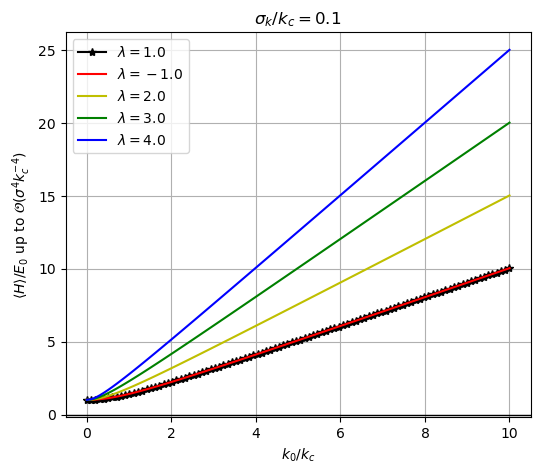

In [8]:
# Group Hkat values
Hkat_list = [Hkat_l0, Hkat_l1, Hkat_l2, Hkat_l3, Hkat_l4]
colors = ['*k', 'r', 'y', 'g', 'b']

# Create main figure
fig, ax = plt.subplots(figsize=(6, 5))

# Iterate over data series
for i, (Hkat_, color) in enumerate(zip(Hkat_list, colors), start=0):
    ax.plot(k0_values, Hkat_, f'-{color}', label=fr'$\lambda = {l[i]}$')

# Labels and grid
ax.set_xlabel(r'$k_0/k_c$')
ax.set_ylabel(fr"$\langle H\rangle/E_0$ up to $\mathcal{{O}}(\sigma^{{{2*n}}}k_c^{{-{2*n}}})$")
ax.legend(loc="upper left")
ax.grid()
ax.axhline(0, color="black", linewidth=1, linestyle="-")
ax.set_title(fr'$\sigma_k/k_c = {sg/kc}$')

#plt.savefig(f"figs/Hkat_O{n}.png", format="png", dpi=300)

# Show the figure
plt.show()

#### $ \langle H^2 \rangle_{\lambda \textrm{Kat}}/E_{0}^{2} \times k_0/k_c$

In [9]:
H2kat_l0 = np.array([h2_lO(n, l[0], sg, kc, k0) for k0 in k0_values])
H2kat_l1 = np.array([h2_lO(n, l[1], sg, kc, k0) for k0 in k0_values])
H2kat_l2 = np.array([h2_lO(n, l[2], sg, kc, k0) for k0 in k0_values])
H2kat_l3 = np.array([h2_lO(n, l[3], sg, kc, k0) for k0 in k0_values])
H2kat_l4 = np.array([h2_lO(n, l[4], sg, kc, k0) for k0 in k0_values])


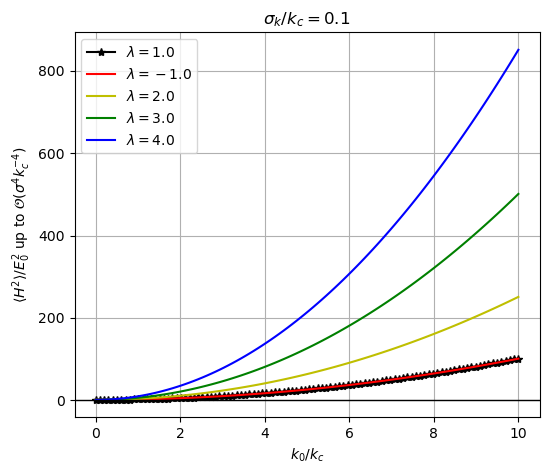

In [10]:
# Group H2kat values
H2kat_list = [H2kat_l0, H2kat_l1, H2kat_l2, H2kat_l3, H2kat_l4]
colors = ['*k', 'r', 'y', 'g', 'b']

# Create main figure
fig, ax = plt.subplots(figsize=(6, 5))

# Iterate over data series
for i, (H2kat_, color) in enumerate(zip(H2kat_list, colors), start=0):
    ax.plot(k0_values, H2kat_, f'-{color}', label=fr'$\lambda = {l[i]}$')

# Labels and grid
ax.set_xlabel(r'$k_0/k_c$')
ax.set_ylabel(fr"$\langle H^2\rangle/E_0^2$ up to $\mathcal{{O}}(\sigma^{{{2*n}}}k_c^{{-{2*n}}})$")
ax.legend(loc="upper left")
ax.grid()
ax.axhline(0, color="black", linewidth=1, linestyle="-")
ax.set_title(fr'$\sigma_k/k_c = {sg/kc}$')

#plt.savefig(f"figs/H2kat_O{n}.png", format="png", dpi=300)

# Show the figure
plt.show()

#### $ Var\left[ H \right]_{\lambda \textrm{Kat}}/E_{0}^{2} \times k_0/k_c$

In [11]:
VarHcat_values0 = H2kat_l0 - Hkat_l0**2
VarHcat_values1 = H2kat_l1 - Hkat_l1**2
VarHcat_values2 = H2kat_l2 - Hkat_l2**2
VarHcat_values3 = H2kat_l3 - Hkat_l3**2
VarHcat_values4 = H2kat_l4 - Hkat_l4**2

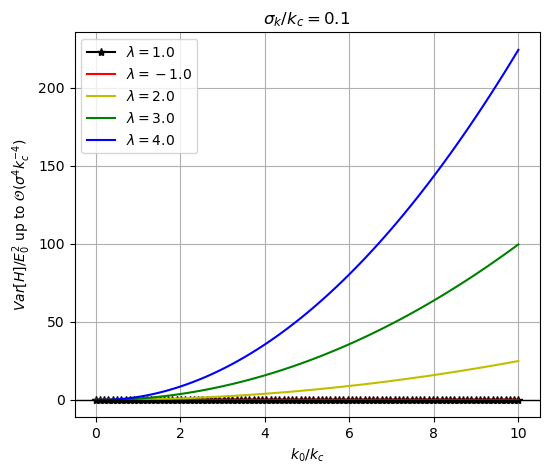

In [12]:
# Group VarHkat values
VarHkat_list = [VarHcat_values0, VarHcat_values1, VarHcat_values2, VarHcat_values3, VarHcat_values4]
colors = ['*k', 'r', 'y', 'g', 'b']

# Create main figure
fig, ax = plt.subplots(figsize=(6, 5))

# Iterate over data series
for i, (VarHkat, color) in enumerate(zip(VarHkat_list, colors), start=0):
    ax.plot(k0_values, VarHkat, f'-{color}', label=fr'$\lambda = {l[i]}$')

# Labels and grid
ax.set_xlabel(r'$k_0/k_c$')
ax.set_ylabel(fr"$Var\left[H\right]/E_0^2$ up to $\mathcal{{O}}(\sigma^{{{2*n}}}k_c^{{-{2*n}}})$")
ax.legend(loc="upper left")
ax.grid()
ax.axhline(0, color="black", linewidth=1, linestyle="-")
ax.set_title(fr'$\sigma_k/k_c = {sg/kc}$')

#plt.savefig(f"figs/VarHkat_O{n}.png", format="png", dpi=300)

# Show the figure
plt.show()

#### Close up

In [13]:
k0_valuescloseup = np.linspace(0, 20, Npoints, endpoint=True) 

Hkat_l0closeup = np.array([h_lO(n, l[0], sg, kc, k0) for k0 in k0_valuescloseup])
Hkat_l1closeup = np.array([h_lO(n, l[1], sg, kc, k0) for k0 in k0_valuescloseup])

H2kat_l0closeup = np.array([h2_lO(n, l[0], sg, kc, k0) for k0 in k0_valuescloseup])
H2kat_l1closeup = np.array([h2_lO(n, l[1], sg, kc, k0) for k0 in k0_valuescloseup])

VarHcat_values0closeup = H2kat_l0closeup - Hkat_l0closeup**2
VarHcat_values1closeup = H2kat_l1closeup - Hkat_l1closeup**2

VarHcat_values0closeuprel = (H2kat_l0closeup - Hkat_l0closeup**2)/Hkat_l0closeup**2
VarHcat_values1closeuprel = (H2kat_l1closeup - Hkat_l1closeup**2)/Hkat_l1closeup**2

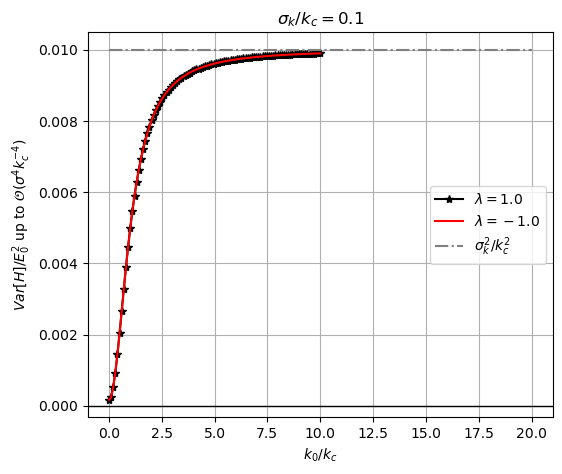

In [14]:
# Group varHkat values
VarHkat_list = [VarHcat_values0, VarHcat_values1]
colors = ['*k', 'r']

# Create main figure
fig, ax = plt.subplots(figsize=(6, 5))

# Iterate over data series
for i, (VarHkat, color) in enumerate(zip(VarHkat_list, colors), start=0):
    ax.plot(k0_values, VarHkat, f'-{color}', label=fr'$\lambda = {l[i]}$')

#ax.plot(k0_valuescloseup, 0*VarHcat_values1closeuprel, '--C7')
ax.plot(k0_valuescloseup, (sg/kc)**2*np.ones(len(VarHcat_values1closeuprel)), '-.C7', label = fr'$\sigma^2_k/k_c^2$') 

# Labels and grid
ax.set_xlabel(r'$k_0/k_c$')
ax.set_ylabel(fr"$Var\left[H\right]/E_0^2$ up to $\mathcal{{O}}(\sigma^{{{2*n}}}k_c^{{-{2*n}}})$")
ax.legend(loc="center right")
ax.grid()
ax.axhline(0, color="black", linewidth=1, linestyle="-")
ax.set_title(fr'$\sigma_k/k_c = {sg/kc}$')

#plt.savefig(f"figs/VarHkat_O{n}closeup.png", format="png", dpi=300)

# Show the figure
plt.show()

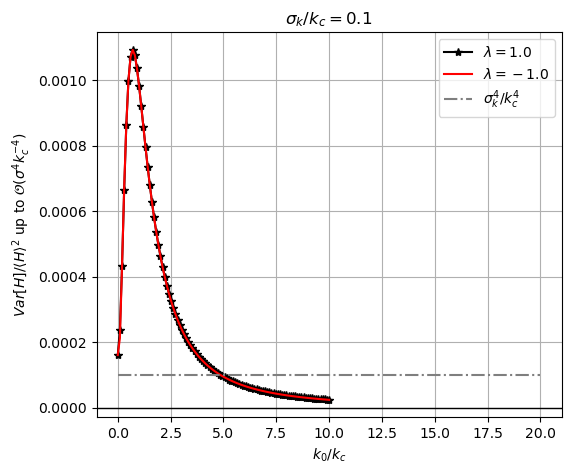

In [15]:
# Group relative VarHkat values
VarHkat_list = [VarHcat_values0/Hkat_l0closeup**2, VarHcat_values1/Hkat_l1closeup**2]
colors = ['*k', 'r']

# Create main figure
fig, ax = plt.subplots(figsize=(6, 5))

# Iterate over data series
for i, (VarHkat, color) in enumerate(zip(VarHkat_list, colors), start=0):
    ax.plot(k0_values, VarHkat, f'-{color}', label=fr'$\lambda = {l[i]}$')
ax.plot(k0_valuescloseup, (sg/kc)**4*np.ones(len(VarHcat_values1closeuprel)), '-.C7', label = fr'$\sigma^4_k/k_c^4$') 

# Labels and grid
ax.set_xlabel(r'$k_0/k_c$')
ax.set_ylabel(fr"$Var\left[H\right]/\langle H\rangle^2$ up to $\mathcal{{O}}(\sigma^{{{2*n}}}k_c^{{-{2*n}}})$")
ax.legend(loc="upper right")
ax.grid()
ax.axhline(0, color="black", linewidth=1, linestyle="-")
ax.set_title(fr'$\sigma_k/k_c = {sg/kc}$')

#plt.savefig(f"figs/rel1VarHkat_O{n}closeup.png", format="png", dpi=300)

# Show the figure
plt.show()

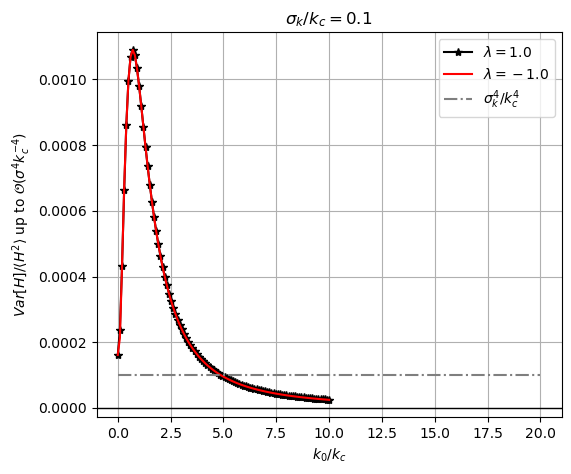

In [16]:
# Group relative VarHkat values
VarHkat_list = [VarHcat_values0/H2kat_l0closeup, VarHcat_values1/H2kat_l1closeup]
colors = ['*k', 'r']

# Create main figure
fig, ax = plt.subplots(figsize=(6, 5))

# Iterate over data series
for i, (VarHkat, color) in enumerate(zip(VarHkat_list, colors), start=0):
    ax.plot(k0_values, VarHkat, f'-{color}', label=fr'$\lambda = {l[i]}$')
ax.plot(k0_valuescloseup, (sg/kc)**4*np.ones(len(VarHcat_values1closeuprel)), '-.C7', label = fr'$\sigma^4_k/k_c^4$') 

# Labels and grid
ax.set_xlabel(r'$k_0/k_c$')
ax.set_ylabel(fr"$Var\left[H\right]/\langle H^2\rangle$ up to $\mathcal{{O}}(\sigma^{{{2*n}}}k_c^{{-{2*n}}})$")
ax.legend(loc="upper right")
ax.grid()
ax.axhline(0, color="black", linewidth=1, linestyle="-")
ax.set_title(fr'$\sigma_k/k_c = {sg/kc}$')

#plt.savefig(f"figs/rel2VarHkat_O{n}closeup.png", format="png", dpi=300)

# Show the figure
plt.show()

NameError: name 'cat' is not defined

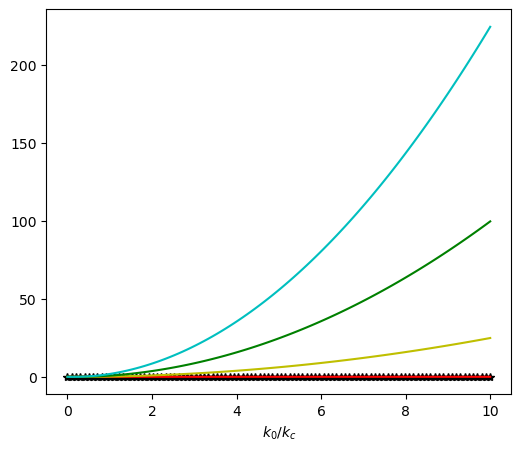

In [17]:
# Group VarHkat values
VarHkat_list = [VarHcat_values0, VarHcat_values1, VarHcat_values2, VarHcat_values3, VarHcat_values4]
colors = ['*k', 'r', 'y', 'g', 'c']

# Create main figure
fig, ax = plt.subplots(figsize=(6, 5))

# Iterate over data series
for i, (VarHkat, color) in enumerate(zip(VarHkat_list, colors), start=0):
    ax.plot(k0_values, VarHkat, f'-{color}', label=fr'$\lambda = {l[i]}$')

# Labels and grid
ax.set_xlabel(r'$k_0/k_c$')
ax.set_ylabel(fr"$Var\left[H\right]_{{k\text{-cat}(\lambda)}}/E_0^2$ up to $\mathcal{{O}}(\sigma^{{{2*n}}}k_c^{{-{2*n}}})$")
ax.legend(loc="upper left")
ax.grid()
ax.axhline(0, color="black", linewidth=1, linestyle="-")
ax.set_title(r'Variance in $|k\text{-cat}(\lambda)\rangle$ (with $\sigma_k/k_c = 0.1$)')

# Create inset plot with log scale
ax_inset = inset_axes(ax, width="40%", height="40%", bbox_to_anchor=(0.273, -0.06, 1.0, 1.0),
                      bbox_transform=ax.transAxes, loc='upper center')
ax_inset.plot(k0_valuescloseup, VarHcat_values0closeup, '-*k')  
ax_inset.plot(k0_valuescloseup, VarHcat_values1closeup, '-r') 
ax_inset.plot(k0_valuescloseup, 0*VarHcat_values1closeuprel, '--C7')
ax_inset.plot(k0_valuescloseup, (sg/kc)**2*np.ones(len(VarHcat_values1closeuprel)), '-.C7') 
#ax_inset.set_xscale("log")  # Log scale for x-axis
#ax_inset.set_yscale("log")  # Log scale for y-axis
#ax_inset.set_title("Log-scale inset", fontsize=10)
#ax_inset.grid()
#plt.savefig(f"figs/VarHkat_O{n}full.png", format="png", dpi=300)
# Show the figure
plt.show()

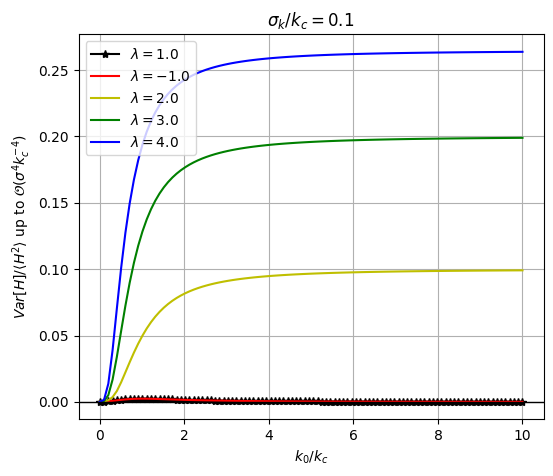

In [ ]:
# Group your H2kat values
VarHkatrel_list = [VarHcat_values0/H2kat_l0, VarHcat_values1/H2kat_l1, VarHcat_values2/H2kat_l2, VarHcat_values3/H2kat_l3, VarHcat_values4/H2kat_l4]
colors = ['*k', 'r', 'y', 'g', 'b']

# Create main figure
fig, ax = plt.subplots(figsize=(6, 5))

# Iterate over data series
for i, (VarHkatrel, color) in enumerate(zip(VarHkatrel_list, colors), start=0):
    ax.plot(k0_values, VarHkatrel, f'-{color}', label=fr'$\lambda = {l[i]}$')

# Labels and grid
ax.set_xlabel(r'$k_0/k_c$')
ax.set_ylabel(fr"$Var\left[H\right]/\langle H^2\rangle$ up to $\mathcal{{O}}(\sigma^{{{2*n}}}k_c^{{-{2*n}}})$")
ax.legend(loc="upper left")
ax.grid()
ax.axhline(0, color="black", linewidth=1, linestyle="-")
ax.set_title(fr'$\sigma_k/k_c = {sg/kc}$')

#plt.savefig(f"figs/rel1VarHkat_O{n}.png", format="png", dpi=300)
# Show the figure
plt.show()

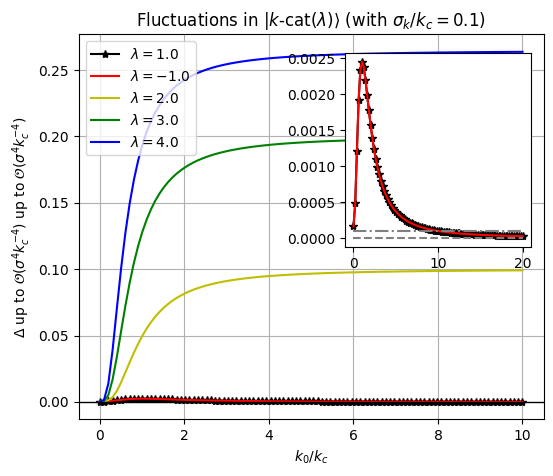

In [ ]:
## Grouprelative VarHkat values
VarHkatrel_list = [VarHcat_values0/H2kat_l0, VarHcat_values1/H2kat_l1, VarHcat_values2/H2kat_l2, VarHcat_values3/H2kat_l3, VarHcat_values4/H2kat_l4]
colors = ['*k', 'r', 'y', 'g', 'b']

# Create main figure
fig, ax = plt.subplots(figsize=(6, 5))

# Iterate over data series
for i, (VarHkatrel, color) in enumerate(zip(VarHkatrel_list, colors), start=0):
    ax.plot(k0_values, VarHkatrel, f'-{color}', label=fr'$\lambda = {l[i]}$')

# Labels and grid
ax.set_xlabel(r'$k_0/k_c$')
ax.set_ylabel(fr"$\Delta$ up to $\mathcal{{O}}(\sigma^{{{2*n}}}k_c^{{-{2*n}}})$ up to $\mathcal{{O}}(\sigma^{{{2*n}}}k_c^{{-{2*n}}})$")
ax.legend(loc="upper left")
ax.grid()
ax.axhline(0, color="black", linewidth=1, linestyle="-")
ax.set_title(r"Fluctuations in $|k\text{-cat}(\lambda)\rangle$ (with $\sigma_k/k_c = 0.1$)")

# Create inset plot with log scale
ax_inset = inset_axes(ax, width="40%", height="40%", bbox_to_anchor=(0.558, 0.43, 1.0, 1.26),
                      bbox_transform=ax.transAxes, loc='lower left')
ax_inset.plot(k0_valuescloseup, VarHcat_values0closeuprel, '-*k')  
ax_inset.plot(k0_valuescloseup, VarHcat_values1closeuprel, '-r')  
ax_inset.plot(k0_valuescloseup, 0*VarHcat_values1closeuprel, '--C7')
ax_inset.plot(k0_valuescloseup, (sg/kc)**4*np.ones(len(VarHcat_values1closeuprel)), '-.C7')

#plt.savefig(f"figs/DeltaHkat_O{n}full.png", format="png", dpi=300)
# Show the figure
plt.show()

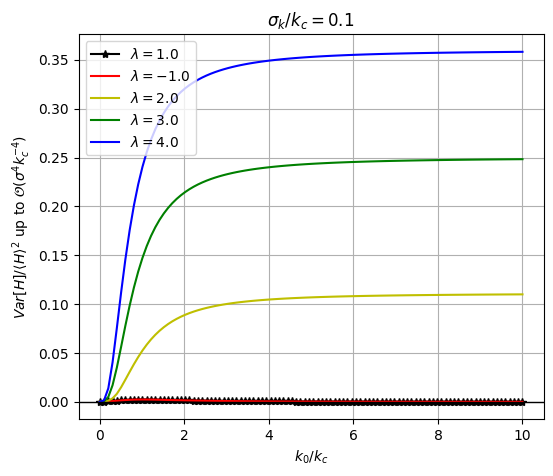

In [ ]:
# Group relative Var kat values
VarHkatrel_list = [VarHcat_values0/Hkat_l0**2, VarHcat_values1/Hkat_l1**2, VarHcat_values2/Hkat_l2**2, VarHcat_values3/Hkat_l3**2, VarHcat_values4/Hkat_l4**2]
colors = ['*k', 'r', 'y', 'g', 'b']

# Create main figure
fig, ax = plt.subplots(figsize=(6, 5))

# Iterate over data series
for i, (VarHkatrel, color) in enumerate(zip(VarHkatrel_list, colors), start=0):
    ax.plot(k0_values, VarHkatrel, f'-{color}', label=fr'$\lambda = {l[i]}$')

# Labels and grid
ax.set_xlabel(r'$k_0/k_c$')
ax.set_ylabel(fr"$Var\left[H\right]/\langle H\rangle^2$ up to $\mathcal{{O}}(\sigma^{{{2*n}}}k_c^{{-{2*n}}})$")
ax.legend(loc="upper left")
ax.grid()
ax.axhline(0, color="black", linewidth=1, linestyle="-")
ax.set_title(fr'$\sigma_k/k_c = {sg/kc}$')

#plt.savefig(f"figs/rel2VarHkat_O{n}.png", format="png", dpi=300)
# Show the figure
plt.show()

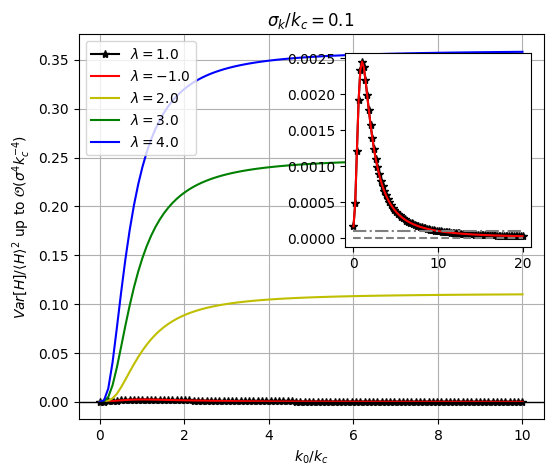

In [ ]:
## Grouprelative VarHkat values
VarHkatrel_list = [VarHcat_values0/Hkat_l0**2, VarHcat_values1/Hkat_l1**2, VarHcat_values2/Hkat_l2**2, VarHcat_values3/Hkat_l3**2, VarHcat_values4/Hkat_l4**2]
colors = ['*k', 'r', 'y', 'g', 'b']

# Create main figure
fig, ax = plt.subplots(figsize=(6, 5))

# Iterate over data series
for i, (VarHkatrel, color) in enumerate(zip(VarHkatrel_list, colors), start=0):
    ax.plot(k0_values, VarHkatrel, f'-{color}', label=fr'$\lambda = {l[i]}$')

# Labels and grid
ax.set_xlabel(r'$k_0/k_c$')
ax.set_ylabel(fr"$Var\left[H\right]/\langle H\rangle^2$ up to $\mathcal{{O}}(\sigma^{{{2*n}}}k_c^{{-{2*n}}})$")
ax.legend(loc="upper left")
ax.grid()
ax.axhline(0, color="black", linewidth=1, linestyle="-")
ax.set_title(fr'$\sigma_k/k_c = {sg/kc}$')

# Create inset plot with log scale
ax_inset = inset_axes(ax, width="40%", height="40%", bbox_to_anchor=(0.558, 0.43, 1.0, 1.26),
                      bbox_transform=ax.transAxes, loc='lower left')
ax_inset.plot(k0_valuescloseup, VarHcat_values0closeuprel, '-*k')  
ax_inset.plot(k0_valuescloseup, VarHcat_values1closeuprel, '-r')  
ax_inset.plot(k0_valuescloseup, 0*VarHcat_values1closeuprel, '--C7')
ax_inset.plot(k0_valuescloseup, (sg/kc)**4*np.ones(len(VarHcat_values1closeuprel)), '-.C7')

#plt.savefig(f"figs/rel2VarHkat_O{n}full.png", format="png", dpi=300)
# Show the figure
plt.show()